In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

plt.style.use("ggplot")

In [4]:
conn = sqlite3.connect("../Database/retail_bi.db")

In [3]:
query = "SELECT COUNT(*) AS total_orders FROM orders"

pd.read_sql(query, conn)

,total_orders
0,99441


In [4]:
query = """
SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(oi.price), 2) AS total_revenue

FROM order_items oi

JOIN orders o
ON oi.order_id = o.order_id

WHERE strftime('%Y', o.order_purchase_timestamp) = '2017'

GROUP BY month

ORDER BY month;
"""

monthly_revenue = pd.read_sql(query, conn)

monthly_revenue

,month,total_revenue
0,2017-01,120312.87
1,2017-02,247303.02
2,2017-03,374344.30
3,2017-04,359927.23
4,2017-05,506071.14
5,2017-06,433038.60
6,2017-07,498031.48
7,2017-08,573971.68
8,2017-09,624401.69
9,2017-10,664219.43


In [5]:
monthly_revenue.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          12 non-null     str    
 1   total_revenue  12 non-null     float64
dtypes: float64(1), str(1)
memory usage: 324.0 bytes


In [6]:
monthly_revenue.head()

,month,total_revenue
0,2017-01,120312.87
1,2017-02,247303.02
2,2017-03,374344.30
3,2017-04,359927.23
4,2017-05,506071.14


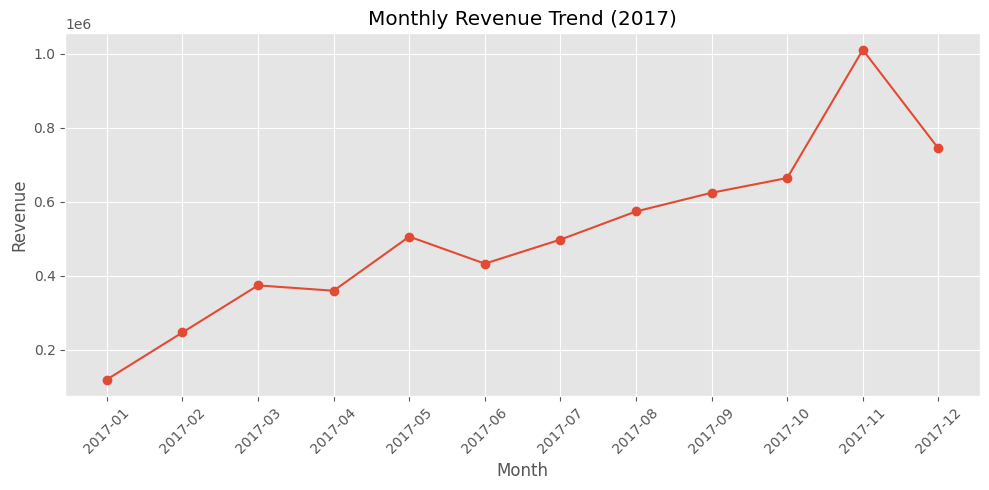

In [7]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend (2017)")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [8]:
query = """
SELECT
    pct.product_category_name_english,
    ROUND(SUM(oi.price),2) AS total_revenue

FROM order_items oi

JOIN products p
ON oi.product_id = p.product_id

JOIN product_category_name_translation pct
ON p.product_category_name = pct.product_category_name

GROUP BY pct.product_category_name_english

ORDER BY total_revenue DESC

LIMIT 10;
"""

category_revenue = pd.read_sql(query, conn)

category_revenue

,product_category_name_english,total_revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


In [9]:
category_revenue.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_category_name_english  10 non-null     str    
 1   total_revenue                  10 non-null     float64
dtypes: float64(1), str(1)
memory usage: 292.0 bytes


In [10]:
category_revenue.head()

,product_category_name_english,total_revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32


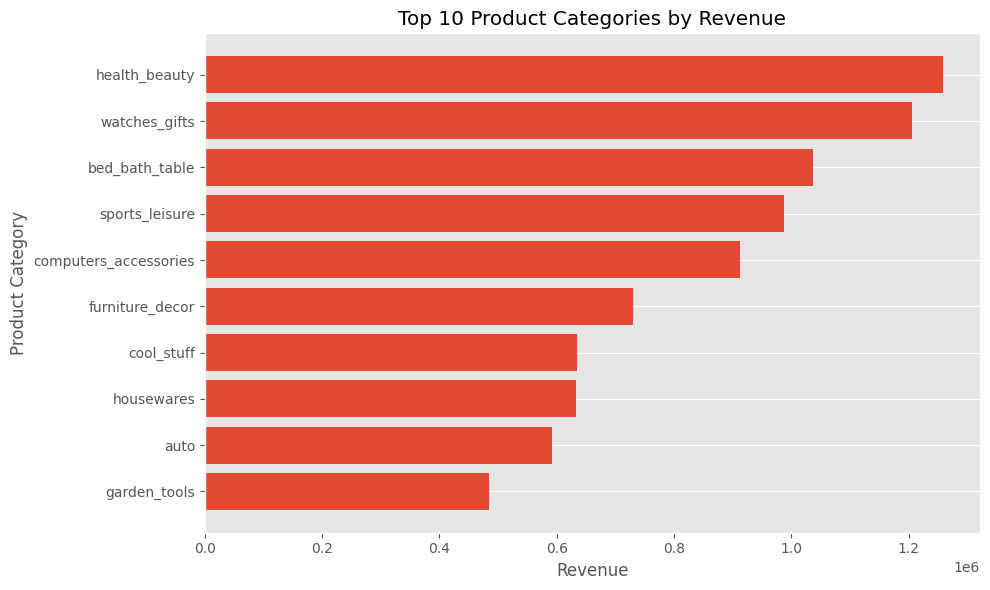

In [11]:
plt.figure(figsize=(10,6))

plt.barh(
    category_revenue["product_category_name_english"],
    category_revenue["total_revenue"],
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue") 
plt.ylabel("Product Category")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.tight_layout()

plt.show()

In [5]:
query="""
SELECT
    customer_state,
    COUNT(DISTINCT customer_unique_id) AS total_customers

FROM customers

GROUP BY customer_state

ORDER BY total_customers DESC;
"""
state_customers = pd.read_sql(query, conn)

state_customers



,customer_state,total_customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


In [6]:
state_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customer_state   27 non-null     str  
 1   total_customers  27 non-null     int64
dtypes: int64(1), str(1)
memory usage: 564.0 bytes


In [7]:
state_customers.head()

,customer_state,total_customers
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882


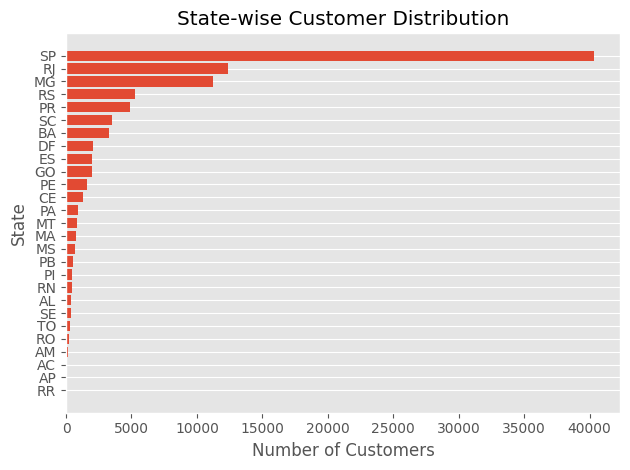

In [9]:
plt.barh(
    state_customers["customer_state"],
    state_customers["total_customers"]
)

plt.title("State-wise Customer Distribution")
plt.xlabel("Number of Customers") 
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.tight_layout()

plt.show()

In [14]:
query = """
SELECT
    payment_type,
    COUNT(*) AS total_payments

FROM order_payments

GROUP BY payment_type

ORDER BY total_payments DESC;
"""

payment_methods = pd.read_sql(query, conn)

payment_methods

,payment_type,total_payments
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


In [15]:
payment_methods.info()
payment_methods.head()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   payment_type    5 non-null      str  
 1   total_payments  5 non-null      int64
dtypes: int64(1), str(1)
memory usage: 212.0 bytes


,payment_type,total_payments
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


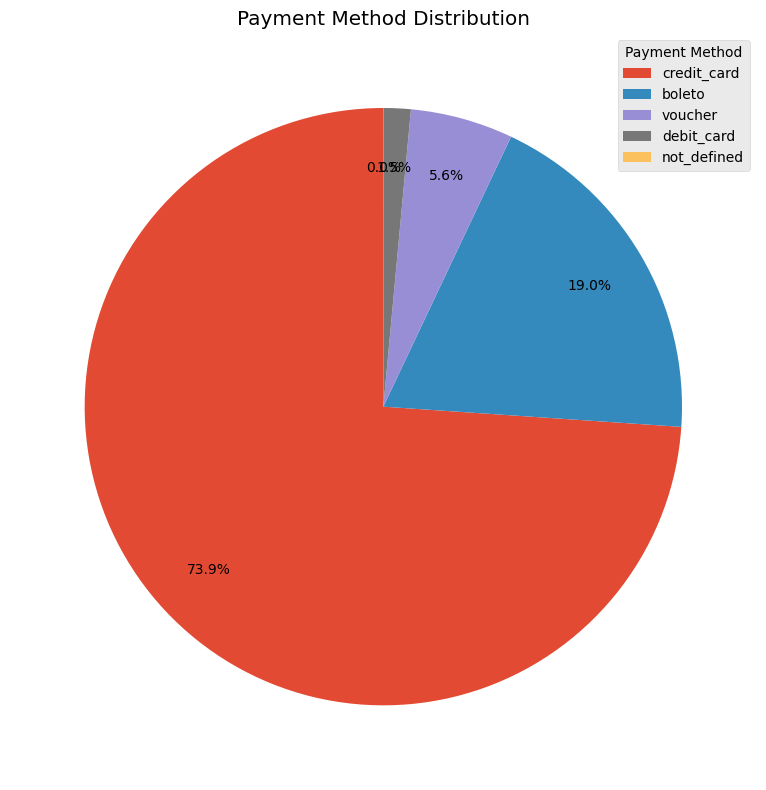

In [22]:
plt.figure(figsize=(8,8))

plt.pie(
    payment_methods["total_payments"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)

plt.title("Payment Method Distribution")

plt.legend(
    payment_methods["payment_type"],
    title="Payment Method",
    loc="upper right"
)

plt.tight_layout()

plt.show()

In [23]:
query = """
SELECT
    CASE
        WHEN review_score = 5 THEN 'Excellent'
        WHEN review_score = 4 THEN 'Good'
        WHEN review_score = 3 THEN 'Average'
        WHEN review_score = 2 THEN 'Poor'
        WHEN review_score = 1 THEN 'Bad'
    END AS review_category,

    COUNT(*) AS total_reviews

FROM order_reviews

GROUP BY review_category

ORDER BY
CASE
    WHEN review_category='Excellent' THEN 1
    WHEN review_category='Good' THEN 2
    WHEN review_category='Average' THEN 3
    WHEN review_category='Poor' THEN 4
    WHEN review_category='Bad' THEN 5
END;
"""
review_distribution = pd.read_sql(query, conn)
review_distribution

,review_category,total_reviews
0,Excellent,57328
1,Good,19142
2,Average,8179
3,Poor,3151
4,Bad,11424


In [24]:
review_distribution.info()
review_distribution.head()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   review_category  5 non-null      str  
 1   total_reviews    5 non-null      int64
dtypes: int64(1), str(1)
memory usage: 212.0 bytes


,review_category,total_reviews
0,Excellent,57328
1,Good,19142
2,Average,8179
3,Poor,3151
4,Bad,11424


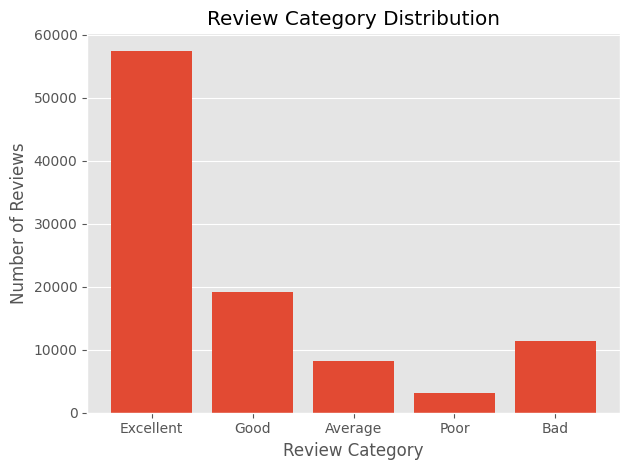

In [30]:
plt.bar(
    review_distribution["review_category"],
    review_distribution["total_reviews"]
)

plt.title("Review Category Distribution")
plt.xlabel("Review Category")
plt.ylabel("Number of Reviews")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

In [31]:
query = """
SELECT
ROUND(
julianday(order_delivered_customer_date) -
julianday(order_purchase_timestamp),2
) AS delivery_days

FROM orders

WHERE order_delivered_customer_date IS NOT NULL;
"""

delivery_time = pd.read_sql(query, conn)

In [32]:
delivery_time.info()
delivery_time.head()

<class 'pandas.DataFrame'>
RangeIndex: 96476 entries, 0 to 96475
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   delivery_days  96476 non-null  float64
dtypes: float64(1)
memory usage: 753.8 KB


,delivery_days
0,8.44
1,13.78
2,9.39
3,13.21
4,2.87


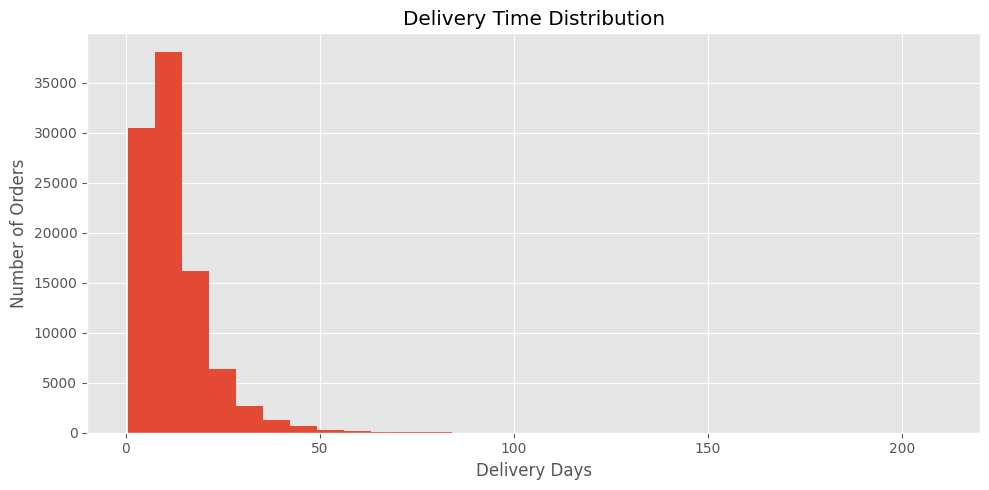

In [42]:
plt.figure(figsize=(10,5))

plt.hist(
    delivery_time["delivery_days"],
    bins=30
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.grid(True)

plt.tight_layout()

plt.show()

In [34]:
query = """
SELECT
    r.review_score,
    ROUND(
        AVG(
            julianday(o.order_delivered_customer_date) -
            julianday(o.order_purchase_timestamp)
        ),2
    ) AS avg_delivery_days

FROM orders o

JOIN order_reviews r
ON o.order_id = r.order_id

WHERE o.order_delivered_customer_date IS NOT NULL

GROUP BY r.review_score

ORDER BY r.review_score DESC;
"""
delivery_reviews = pd.read_sql(query, conn)


In [35]:
delivery_reviews.info()
delivery_reviews.head()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_score       5 non-null      int64  
 1   avg_delivery_days  5 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 212.0 bytes


,review_score,avg_delivery_days
0,5,10.69
1,4,12.31
2,3,14.26
3,2,16.66
4,1,21.31


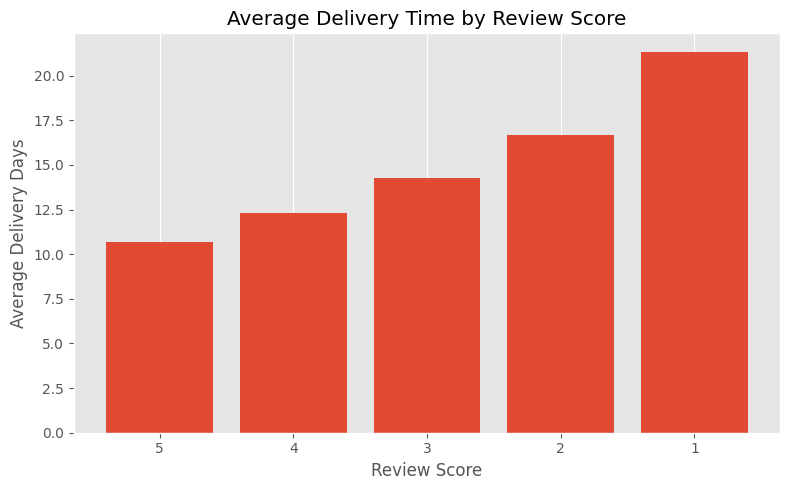

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    delivery_reviews["review_score"].astype(str),
    delivery_reviews["avg_delivery_days"]
)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Days")

plt.grid(axis="y")

plt.tight_layout()

plt.show()